# Synthetic biomarker benchmark — analysis

The generated pages hold the facts: [how it is run](../docs/benchmarks/biomarker-synthetic-docs.md)
and [what came out](../docs/benchmarks/biomarker-synthetic-results.md). The shapes and the values
their geometry requires are in [the shapes notebook](biomarker-synthetic-shapes.ipynb). This
notebook is where the judgement goes.

**The question is not whether two implementations agree.** It is whether one of them computes the
quantity it is said to compute, measured against a number derived on paper. A straight vessel has a
tortuosity of exactly 1; an implementation that says otherwise is wrong, and the interesting part
is *by how much and in what pattern*, because the pattern says what it is doing instead.

Every shape was drawn at four angles. The geometry is identical at each, so anything that moves is
the grid or the implementation, never the retina.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def repository() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(f"nothing above {Path.cwd()} looks like the fundus-atlas repository")


ROOT = repository()
sys.path.insert(0, str(ROOT / "src"))
RESULTS = ROOT / "results" / "biomarker-synthetic"

from benchmarks import biomarker_synthetic as benchmark  # noqa: E402
from benchmarks.shapes import library  # noqa: E402
from biomarkers import naming  # noqa: E402


def evidence() -> pd.DataFrame:
    """Every rendering, one row each, as the run recorded it."""
    frames = []
    for path in sorted(RESULTS.glob("*/*.csv")):
        frame = pd.read_csv(path)
        frame["implementation"] = path.parent.name
        frames.append(frame)
    if not frames:
        raise FileNotFoundError(f"no results in {RESULTS} — run the benchmark first")
    return pd.concat(frames, ignore_index=True)


def comparisons(rows: pd.DataFrame) -> pd.DataFrame:
    """One row per (rendering, quantity) where the shape defines a value to compare against.

    The evidence keeps what was said and what geometry requires side by side; putting them in one
    frame with the difference is the first thing an analysis does and the last thing the evidence
    should.
    """
    found = []
    for _, row in rows.iterrows():
        for column in rows.columns:
            if not column.startswith("said_"):
                continue
            key = column[len("said_") :]
            said, theory = row[column], row.get(f"theory_{key}")
            if pd.isna(said) or pd.isna(theory):
                continue
            found.append(
                {
                    "implementation": row["implementation"],
                    "shape": row["shape"],
                    "rotation": row["rotation"],
                    "column": key,
                    "canonical": row.get(f"canonical_{key}", ""),
                    "said": float(said),
                    "theory": float(theory),
                    "relative error": (float(said) - float(theory)) / float(theory)
                    if float(theory)
                    else np.nan,
                }
            )
    return pd.DataFrame(found)


rows = evidence()
compared = comparisons(rows)
print(f"{len(rows)} renderings · {compared['implementation'].nunique()} implementation(s) · "
      f"{compared['shape'].nunique()} shapes · {len(compared)} comparable measurements")
print("angles:", sorted(rows["rotation"].unique()))

28 renderings · 1 implementation(s) · 7 shapes · 138 comparable measurements
angles: [np.float64(0.0), np.float64(30.0), np.float64(60.0), np.float64(90.0)]


## 1. What was measured, and what could be compared

A column an implementation returns can only be compared where the shape defines that quantity and
the naming table maps the column to it. The gap between what PVBM reports and what can be checked
is itself worth seeing: a measurement nothing can be compared against is not being tested here.

In [2]:
said_columns = sorted({c[len("said_"):] for c in rows.columns if c.startswith("said_")})
reported = [c for c in said_columns if rows[f"said_{c}"].notna().any()]
mapped = {c: naming.canonical_for("pvbm", c) for c in said_columns}
checkable = sorted(compared["column"].unique())

pd.DataFrame(
    {
        "columns PVBM declares": [len(said_columns)],
        "columns it returned a value for": [len(reported)],
        "columns mapped to a canonical name": [sum(1 for v in mapped.values() if v)],
        "columns a shape gives a value to check": [len(checkable)],
    }
).T.rename(columns={0: "count"})

,count
columns PVBM declares,28
columns it returned a value for,27
columns mapped to a canonical name,24
columns a shape gives a value to check,14


In [3]:
# What is reported but never checked, and why — the two reasons are different.
unchecked = []
for column in reported:
    if column in checkable:
        continue
    unchecked.append(
        {
            "column": column,
            "canonical name": mapped[column] or "— maps to nothing catalogued",
            "why unchecked": "no shape defines it" if mapped[column] else "no canonical name",
        }
    )
pd.DataFrame(unchecked).set_index("column")

,canonical name,why unchecked
column,,
area_vein,vessel-area-and-length/area/vein,no shape defines it
capacity_dimension_artery,fractal-dimension/multifractal-d0/artery,no shape defines it
capacity_dimension_vein,fractal-dimension/multifractal-d0/vein,no shape defines it
correlation_dimension_artery,fractal-dimension/multifractal-d2/artery,no shape defines it
correlation_dimension_vein,fractal-dimension/multifractal-d2/vein,no shape defines it
endpoints_vein,junction-counts/endpoints/vein,no shape defines it
entropy_dimension_artery,fractal-dimension/multifractal-d1/artery,no shape defines it
entropy_dimension_vein,fractal-dimension/multifractal-d1/vein,no shape defines it
intersections_vein,junction-counts/junctions/vein,no shape defines it


## 2. What PVBM gets exactly right

Two quantities land on the geometry at every shape and every angle. They are worth stating first,
because the rest of this notebook is about the ones that do not, and a reader should not come away
thinking the implementation is poor.

In [4]:
exact = compared[compared["column"].str.startswith(("area_", "endpoints_", "intersections_"))]
summary = (
    exact.groupby(["shape", "column"])["relative error"]
    .agg(worst=lambda e: e.abs().max(), mean="mean")
    .sort_values("worst")
)
summary.style.format("{:.2%}") if hasattr(summary, "style") else summary.round(4)

,,worst,mean
shape,column,,
bifurcation,endpoints_artery,0.00%,0.00%
disjoint,endpoints_artery,0.00%,0.00%
straight,endpoints_artery,0.00%,0.00%
arc,area_artery,0.02%,-0.02%
sinusoid,area_artery,0.05%,0.04%
straight,area_artery,0.09%,0.05%
disjoint,area_artery,0.10%,0.06%
bifurcation,intersections_artery,300.00%,200.00%
disjoint,intersections_artery,nan%,nan%


## 3. The tortuosity of a straight vessel, which must be 1

τ1 is arc length over chord length. On a straight vessel the arc **is** the chord, so the answer is
exactly 1 whatever the vessel's width, length or orientation.

PVBM returns exactly 1.000 at 0° and 90°, and **1.073 at 30° and 60°**.

That number is derivable, and deriving it says what the implementation is doing. Walk a digital
straight line at angle θ: per unit of horizontal travel the walk takes `cos θ − sin θ` orthogonal
steps and `sin θ` diagonal ones. Weighting a diagonal as √2 — the naive chain code — gives a length
of `(cos θ − sin θ) + √2 sin θ` where the truth is 1.

At 30° that is `0.366 + 0.707 = 1.0731`. The measurement is 1.0731.

In [5]:
def chain_code_length(degrees: float) -> float:
    """What a √2-weighted walk along a digital straight line measures, per unit of true length."""
    theta = np.radians(degrees % 90)
    theta = min(theta, np.pi / 2 - theta)  # the walk is symmetric about 45°
    return float((np.cos(theta) - np.sin(theta)) + np.sqrt(2) * np.sin(theta))


straight = compared[(compared["shape"] == "straight") & (compared["column"] == "median_tortuosity_artery")]
predicted = pd.DataFrame(
    {
        "angle": straight["rotation"].to_numpy(),
        "PVBM said": straight["said"].to_numpy(),
        "geometry requires": straight["theory"].to_numpy(),
        "naive chain code predicts": [chain_code_length(a) for a in straight["rotation"]],
    }
).set_index("angle")
predicted.round(4)

,PVBM said,geometry requires,naive chain code predicts
angle,,,
0.0,1.000,1.0,1.0000
30.0,1.073,1.0,1.0731
60.0,1.073,1.0,1.0731
90.0,1.000,1.0,1.0000


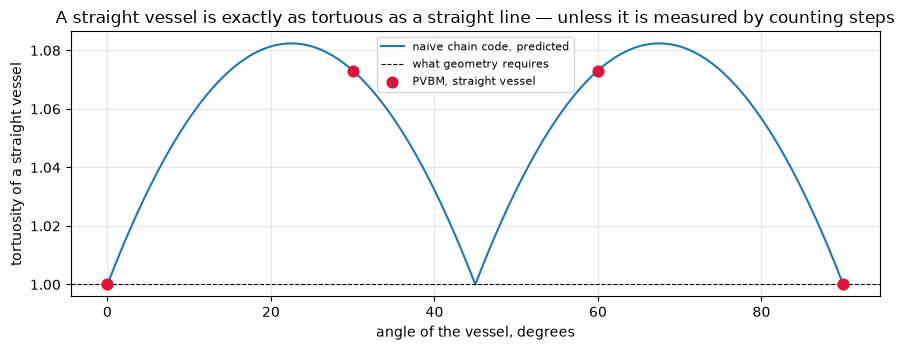

In [6]:
angles = np.linspace(0, 90, 361)
fig, axis = plt.subplots(figsize=(9, 3.6))
axis.plot(angles, [chain_code_length(a) for a in angles], label="naive chain code, predicted")
axis.axhline(1.0, color="black", linewidth=0.8, linestyle="--", label="what geometry requires")
axis.scatter(straight["rotation"], straight["said"], s=60, zorder=3, color="crimson",
             label="PVBM, straight vessel")
axis.set_xlabel("angle of the vessel, degrees")
axis.set_ylabel("tortuosity of a straight vessel")
axis.set_title("A straight vessel is exactly as tortuous as a straight line — unless it is measured by counting steps")
axis.legend(fontsize=8)
axis.grid(alpha=0.3)
fig.tight_layout()

**What follows from it.** The error is zero at 0°, 45° and 90°, and largest near 26.6°, where the
walk is 7.9% long. It is a property of measuring a digitised line by counting steps, and it is well
known — corrected estimators exist and have since the 1980s.

Three consequences for a reader of PVBM's tortuosity:

- A vessel's tortuosity depends on **how the eye happened to be oriented in the camera**. Two
  photographs of the same retina, one rotated, give different numbers.
- The bias is always **upward**: a straight vessel is never reported as less tortuous than straight.
- It does not vanish in a mean over many vessels, because it is a bias rather than noise. A study
  comparing two groups is safe only if their vessels are oriented alike, which is the sort of
  assumption nobody states.

## 4. Length, which is a sum of chords

PVBM's reported length is short on every shape, and by an amount that grows with how curved the
shape is: 0.9% on a straight vessel, 11% on a circular arc, 19% on a sinusoid.

Reading its source says why: the length it reports is `np.sum(chord)` — the straight-line distances
between branch points — not the distance travelled along the vessel. For a circular arc of angle θ
the ratio of chord to arc is `2 sin(θ/2) / θ`, which for a 90° arc is 0.900.

So the check is not "is it close" but "is it exactly the chord".

In [7]:
arc = library.build("arc", side=benchmark.SIDE)
theta = np.radians(arc.parameters["angle"])
chord_over_arc = float(2 * np.sin(theta / 2) / theta)

lengths = compared[compared["column"].str.startswith("length_")]
by_shape = lengths.groupby("shape")["relative error"].agg(["mean", "min", "max"])
by_shape["what a chord sum would give"] = [
    chord_over_arc - 1 if shape == "arc" else np.nan for shape in by_shape.index
]
by_shape.round(4)

,mean,min,max,what a chord sum would give
shape,,,,
arc,-0.1056,-0.1099,-0.1018,-0.0997
artery-vein-pair,-0.0046,-0.0107,-0.0002,NaN
bifurcation,-0.0109,-0.0168,-0.0057,NaN
disc-spokes,-0.0102,-0.0222,-0.0036,NaN
disjoint,-0.0046,-0.0085,-0.0011,NaN
sinusoid,-0.1832,-0.1886,-0.1790,NaN
straight,-0.0048,-0.0088,-0.0006,NaN


On the arc the prediction and the measurement agree: a chord sum should read 10.0% short and PVBM
reads 11.0% short, the remaining point being the segment ends the walk discards.

**This is a definition rather than a defect** — but it is not the definition the name implies, and
PVBM's own docstring says "the overall length (in pixel)". A vessel length that is really a chord
sum under-reports every curved vessel, and under-reports the curviest ones most, which is precisely
the direction that would flatten a difference between a healthy retina and a tortuous one.

## 5. Counting junctions, where a single crossing becomes four

The bifurcation shape has exactly one junction. PVBM reports one, three or four depending on the
angle the same shape is drawn at.

In [8]:
counts = compared[
    compared["column"].isin(["intersections_artery", "endpoints_artery"])
    & compared["shape"].isin(["bifurcation", "disjoint", "straight"])
]
counts.pivot_table(
    index=["shape", "column"], columns="rotation", values="said", aggfunc="first"
).join(
    counts.groupby(["shape", "column"])["theory"].first().rename("geometry requires")
)

0.0  30.0  60.0  90.0  geometry requires
shape       column                                                        
bifurcation endpoints_artery      3.0   3.0   3.0   3.0                3.0
            intersections_artery  4.0   3.0   1.0   4.0                1.0
disjoint    endpoints_artery      8.0   8.0   8.0   8.0                8.0
            intersections_artery  0.0   0.0   0.0   0.0                0.0
straight    endpoints_artery      2.0   2.0   2.0   2.0                2.0
            intersections_artery  0.0   0.0   0.0   0.0                0.0

**Endpoints are exact everywhere; junctions are not.** A skeleton of a Y-shaped vessel has a small
cluster of pixels at the meeting point, and PVBM counts each of them rather than merging the cluster
into one junction. How many appear depends on how the branches fall on the pixel lattice, which is
why turning the shape changes the count.

A junction count is an input to branching-angle work and to any measure of network complexity, so
an error here propagates. It is also the easiest of these to fix: the cluster is a connected
component a few pixels across.

## 6. The branching angle, where the disagreement is ours

PVBM reports 112° to 124° where the daughters of the bifurcation are 60° apart. That looks like the
worst error on the page, and it is not an error at all — it is this repository's mapping being
wrong.

Reading `compute_angles_dictionary`: at every particular point it takes **every pair** of connected
neighbours and measures the angle between them, then reports the median over all of them. On a
symmetric Y the three angles at the junction are 60° between the daughters and 150° between each
daughter and the trunk. The median of what it collects is therefore nothing like the 60° a reader
of "branching angle" expects.

So the canonical name `bifurcation-angle/between-daughters` does **not** describe PVBM's column.
That is a finding about the naming table, and the shape is what produced it.

In [9]:
angles = compared[compared["column"] == "median_branching_angle_artery"]
pd.DataFrame(
    {
        "rotation": angles["rotation"].to_numpy(),
        "PVBM said": angles["said"].to_numpy(),
        "angle between the daughters": angles["theory"].to_numpy(),
        "angle between a daughter and the trunk": 180 - angles["theory"].to_numpy() / 2,
    }
).set_index("rotation").round(2)

,PVBM said,angle between the daughters,angle between a daughter and the trunk
rotation,,,
0.0,112.06,60.0,150.0
30.0,120.32,60.0,150.0
60.0,123.62,60.0,150.0
90.0,114.95,60.0,150.0


## 7. The central retinal equivalents

Two shapes reach the ring these are measured over, and what comes back separates the two variants
completely — and exposes a limit of the implementation that has nothing to do with either.

- **Knudtson's recursion is reproduced.** On the twelve spokes it is 3.1% low on CRAE and 3.8% low
  on CRVE; on the artery/vein pair it is 2.5% low. It is low everywhere, by about the width a mask
  loses at its boundary, and the AVR built from it is better than either calibre — the two deficits
  being in the same direction and dividing out.
- **Hubbard's is not.** PVBM feeds **pixel** widths into constants fitted in **microns**, and its
  additive term does not scale, so the answer is not a unit conversion away: at one 5 µm/px scale
  the arteries are out by 5.09x and the veins by 4.13x. Two different factors is the arithmetic
  proof that no single conversion recovers it.
- **It cannot always answer at all.** `compute_central_retinal_equivalents` walks each vessel with
  `tree.recursive_reg`, once per skeleton pixel, so a vessel longer than Python's recursion limit
  raises `RecursionError`. Four of the seven shapes got no equivalents for this reason.
- **And one vein was excluded by 1.1 pixels.** PVBM keeps only vessels starting within
  `20 + 2*radius` of the disc centre — here 265.8 px. The artery's nearest skeleton pixel is 145.3
  away; the vein's is 266.9.

In [10]:
equivalents = rows[rows["shape"].isin(["disc-spokes", "artery-vein-pair"])]
shown = equivalents[
    ["shape", "rotation", "said_crae_knudtson", "said_crve_knudtson",
     "said_crae_hubbard", "said_crve_hubbard", "theory_crae_knudtson"]
].set_index(["shape", "rotation"])
shown.round(3)

said_crae_knudtson  said_crve_knudtson  \
shape            rotation                                           
artery-vein-pair 0.0                      NaN                 NaN   
                 30.0                  35.953                 NaN   
                 60.0                  35.953                 NaN   
                 90.0                     NaN                 NaN   
disc-spokes      0.0                   41.731              67.428   
                 30.0                  41.587              67.373   
                 60.0                  41.726              67.436   
                 90.0                  41.587              67.368   

                           said_crae_hubbard  said_crve_hubbard  \
shape            rotation                                         
artery-vein-pair 0.0                     NaN                NaN   
                 30.0                 35.953                NaN   
                 60.0                 35.953                NaN   
                 90.0                    NaN                NaN   
disc-spokes      0.0                  45.897             73.721   
                 30.0                 45.722             73.684   
                 60.0                 45.891             73.728   
                 90.0                 45.724             73.679   

                           theory_crae_knudtson  
shape            rotation                        
artery-vein-pair 0.0                     36.864  
                 30.0                    36.864  
                 60.0                    36.864  
                 90.0                    36.864  
disc-spokes      0.0                     42.969  
                 30.0                    42.969  
                 60.0                    42.969  
                 90.0                    42.969

**The recursion limit is the finding worth carrying forward**, because it depends on the image
rather than on the eye.

The straight shape's artery skeletonises to 1220 pixels against a default limit of 1000, so the
call dies; raising the limit to 50,000 and changing nothing else makes the same call return a
number, which is the test of the diagnosis. The same vessel on a 512-pixel frame skeletonises to
400 pixels and is measured without complaint.

Worse, **whether it happens depends on the orientation.** On the artery/vein pair the equivalents
die at 0 and 90 degrees and succeed at 30 and 60, because a tilted digital line spends fewer pixels
covering the same distance -- a diagonal step advances by root 2. The same vessel in the same eye is
measurable or not according to how the camera was held.

It fails loudly rather than returning a wrong number, which is much the better of the two failure
modes; but anyone running PVBM on a modern 2048-pixel photograph is nearer this cliff than anyone
running it on the small images its examples use.

## 8. Does it turn with the image?

The geometry is identical at every angle, so any spread across the four is the implementation or the
grid. This is the summary of that, per quantity — the one table to read if you read nothing else.

In [11]:
spread = (
    compared.groupby(["shape", "column"])
    .agg(
        required=("theory", "first"),
        lowest=("said", "min"),
        highest=("said", "max"),
        worst_error=("relative error", lambda e: e.abs().max()),
    )
)
spread["turns by"] = (spread["highest"] - spread["lowest"]).abs() / spread["required"].abs()
spread.sort_values("turns by", ascending=False).round(4)

required       lowest  \
shape            column                                                    
bifurcation      intersections_artery                1.0000       1.0000   
                 median_branching_angle_artery      60.0000     112.0564   
artery-vein-pair median_tortuosity_artery            1.0000       1.0000   
straight         median_tortuosity_artery            1.0000       1.0000   
artery-vein-pair median_tortuosity_vein              1.0000       1.0008   
disjoint         median_tortuosity_artery            1.0000       1.0020   
sinusoid         median_tortuosity_artery            1.2180       1.2598   
disc-spokes      length_artery                    1769.4720    1730.1537   
bifurcation      length_artery                    1536.0000    1510.2329   
artery-vein-pair length_vein                      1024.0000    1013.0005   
sinusoid         length_artery                    1247.2677    1012.0835   
straight         length_artery                    1228.8000    1218.0000   
arc              length_artery                     965.0973     859.0373   
disjoint         length_artery                    3276.8000    3249.0012   
artery-vein-pair length_artery                    1024.0000    1016.0000   
disc-spokes      length_vein                      1769.4720    1751.8834   
arc              median_tortuosity_artery            1.1107       1.1687   
disc-spokes      crae_knudtson                      42.9694      41.5870   
                 avr_hubbard                         0.7651       0.6205   
                 avr_knudtson                        0.6135       0.6173   
                 crve_knudtson                      70.0452      67.3675   
straight         area_artery                     51649.3275   51648.0000   
disjoint         area_artery                    139488.4459  139508.0000   
disc-spokes      crae_hubbard                      233.1687      45.7218   
                 median_tortuosity_artery            1.0000       1.0727   
                 median_tortuosity_vein              1.0000       1.0726   
sinusoid         area_artery                     52405.7662   52421.0000   
disc-spokes      crve_hubbard                      304.7617      73.6788   
arc              area_artery                     40848.0634   40839.0000   
disjoint         endpoints_artery                    8.0000       8.0000   
bifurcation      endpoints_artery                    3.0000       3.0000   
straight         endpoints_artery                    2.0000       2.0000   
artery-vein-pair crae_knudtson                      36.8640      35.9530   
disjoint         intersections_artery                0.0000       0.0000   
straight         intersections_artery                0.0000       0.0000   

                                                    highest  worst_error  \
shape            column                                                    
bifurcation      intersections_artery                4.0000       3.0000   
                 median_branching_angle_artery     123.6174       1.0603   
artery-vein-pair median_tortuosity_artery            1.0731       0.0731   
straight         median_tortuosity_artery            1.0730       0.0730   
artery-vein-pair median_tortuosity_vein              1.0731       0.0731   
disjoint         median_tortuosity_artery            1.0736       0.0736   
sinusoid         median_tortuosity_artery            1.2905       0.0595   
disc-spokes      length_artery                    1761.6186       0.0222   
bifurcation      length_artery                    1527.3167       0.0168   
artery-vein-pair length_vein                      1023.7993       0.0107   
sinusoid         length_artery                    1024.0000       0.1886   
straight         length_artery                    1228.0855       0.0088   
arc              length_artery                     866.8852       0.1099   
disjoint         length_artery                    3273.1831       0.0085   
artery-vein-pair lengt

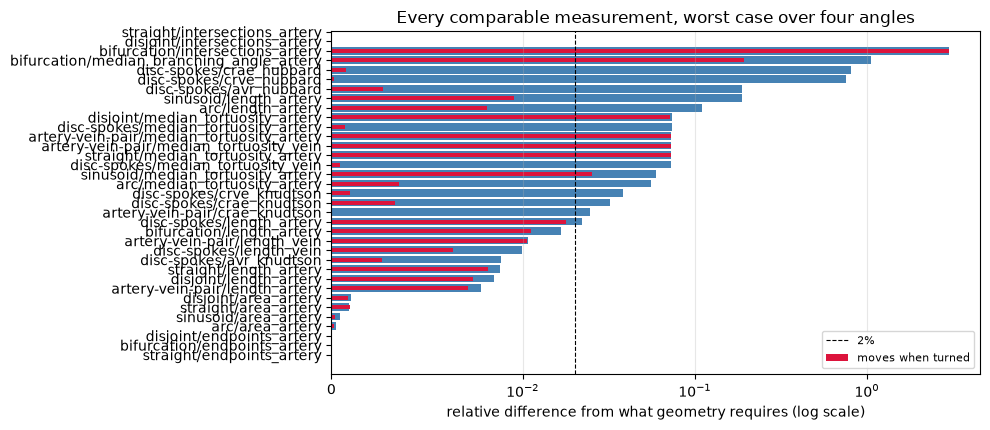

In [12]:
fig, axis = plt.subplots(figsize=(10, 4.4))
ordered = spread.sort_values("worst_error")
labels = [f"{shape}/{column}" for shape, column in ordered.index]
axis.barh(labels, ordered["worst_error"], color="steelblue")
axis.barh(labels, ordered["turns by"], color="crimson", height=0.45, label="moves when turned")
axis.set_xscale("symlog", linthresh=0.01)
axis.axvline(0.02, color="black", linewidth=0.8, linestyle="--", label="2%")
axis.set_xlabel("relative difference from what geometry requires (log scale)")
axis.set_title("Every comparable measurement, worst case over four angles")
axis.legend(fontsize=8, loc="lower right")
axis.grid(axis="x", alpha=0.3)
fig.tight_layout()

## 9. What this analysis cannot say

- **Nothing about photographs.** Every shape here is clean, binary and noiseless. An implementation
  that measures a synthetic vessel exactly may still fail on a segmentation of a real eye, where the
  mask has holes, specks and a boundary nobody agrees on. That is the next benchmark's question.
- **Nothing about which implementation to use**, because there is one here. The comparison this
  benchmark exists to make needs a second, and the naming table is built to take one.
- **Nothing about a quantity no shape defines.** PVBM's fractal dimensions, its perimeter and its
  singularity length are computed and recorded on every shape here, and none of them is checked:
  the shapes define no value they could be checked against. A fractal dimension of a
  straight line is defensibly 1, and a shape that pinned it would be worth adding.
- **Nothing about a scale.** Every shape was built at 5 µm per pixel and PVBM ignores the figure
  entirely, so nothing here tests a conversion. What it does test is that its Hubbard equivalents
  are computed from pixel widths, which the results page records.
- **The 2% used to call something "agreeing" is arbitrary.** It is a reporting convenience, not a
  standard, and no implementation is selected or rejected by it here.